# Analyse comparative — Black-Litterman avec vs sans données textuelles

Ce notebook compare les mêmes modèles LLM dans deux configurations :

1. **Avec texte** : les vues LLM sont générées avec les métadonnées, les rendements passés et `summary_json`.
2. **Sans texte** : les vues LLM sont générées seulement avec les métadonnées et les rendements passés.

Les benchmarks `SP500 (SPY)`, `EW` et `MVO` sont chargés une seule fois avec la même logique que dans le notebook original afin qu’ils soient identiques pour les deux comparaisons.

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from pathlib import Path
import os
import glob

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")

# ---------------------------------------------------------------------
# Paramètres principaux
# ---------------------------------------------------------------------
START = "2015-01-01"
END   = "2025-06-30"

# START = "2024-10-01"

TAU = 0.025

# Noms des modèles tels qu'ils apparaissent dans les fichiers
MODELS = ["gpt", "gemma3", "qwen", "llama"]

# Noms d'affichage
MODEL_LABELS = {
    "gpt": "GPT",
    "gemma3": "Gemma3",
    "qwen": "Qwen2.5",
    "llama": "Llama3.2",
}

# ---------------------------------------------------------------------
# Détection robuste des chemins
# ---------------------------------------------------------------------
CURRENT_DIR = Path.cwd().resolve()

if CURRENT_DIR.name == "no_textual_data_version":
    NO_TEXT_DIR = CURRENT_DIR
    ROOT_DIR = CURRENT_DIR.parent
else:
    ROOT_DIR = CURRENT_DIR
    NO_TEXT_DIR = ROOT_DIR / "no_textual_data_version"

TEXT_RESULTS_DIR = ROOT_DIR / "results"
NO_TEXT_RESULTS_DIR = NO_TEXT_DIR / "results_returns_metadata_only"
PORT_DIR = ROOT_DIR / "responses_portfolios"
DATA_DIR = ROOT_DIR / "data"
RISK_FREE_CSV = DATA_DIR / "DGS1.csv"

print("ROOT_DIR            :", ROOT_DIR)
print("TEXT_RESULTS_DIR    :", TEXT_RESULTS_DIR)
print("NO_TEXT_RESULTS_DIR :", NO_TEXT_RESULTS_DIR)
print("PORT_DIR            :", PORT_DIR)
print("RISK_FREE_CSV       :", RISK_FREE_CSV)


ROOT_DIR            : C:\Users\alexi\OneDrive\Documents\école\ESG\Essai\ESSAI-BLM-LLM
TEXT_RESULTS_DIR    : C:\Users\alexi\OneDrive\Documents\école\ESG\Essai\ESSAI-BLM-LLM\results
NO_TEXT_RESULTS_DIR : C:\Users\alexi\OneDrive\Documents\école\ESG\Essai\ESSAI-BLM-LLM\no_textual_data_version\results_returns_metadata_only
PORT_DIR            : C:\Users\alexi\OneDrive\Documents\école\ESG\Essai\ESSAI-BLM-LLM\responses_portfolios
RISK_FREE_CSV       : C:\Users\alexi\OneDrive\Documents\école\ESG\Essai\ESSAI-BLM-LLM\data\DGS1.csv


## 1. Fonctions utilitaires

In [21]:
def _find_date_col(df: pd.DataFrame) -> str:
    for c in ["date_key", "Date", "date", "ym"]:
        if c in df.columns:
            return c
    if len(df.columns) > 0 and str(df.columns[0]).lower().startswith("unnamed"):
        return df.columns[0]
    raise ValueError(f"Aucune colonne de date trouvée. Colonnes: {list(df.columns)}")


def _read_and_standardize_df(path: str | Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    date_col = _find_date_col(df)

    if date_col == "ym":
        df["date_key"] = pd.to_datetime(df["ym"].astype(str) + "-01", errors="coerce")
    else:
        df["date_key"] = pd.to_datetime(df[date_col], errors="coerce")

    drop_cols = [c for c in ["Date", "date", "ym"] if c in df.columns and c != "date_key"]
    df = df.drop(columns=drop_cols, errors="ignore")
    df = df.dropna(subset=["date_key"]).copy()
    return df


def combine_monthly_portfolios(pattern: str, out_path: str | Path) -> pd.DataFrame:
    """
    Même logique que dans le notebook original :
    combine les fichiers mensuels EW/MVO, trie les dates et garde la dernière observation par mois.
    """
    out_path = Path(out_path)
    files = sorted(glob.glob(str(PORT_DIR / pattern)))

    if not files:
        raise FileNotFoundError(f"Aucun fichier trouvé avec le pattern: {PORT_DIR / pattern}")

    dfs = []
    for f in files:
        df = _read_and_standardize_df(f)
        df["source_file"] = os.path.basename(f)
        dfs.append(df)

    out = pd.concat(dfs, ignore_index=True)
    out = out.sort_values("date_key")
    out = out.drop_duplicates(subset=["date_key"], keep="last").reset_index(drop=True)

    out_path.parent.mkdir(parents=True, exist_ok=True)
    out.to_csv(out_path, index=False)
    return out


def _standardize_returns(df: pd.DataFrame, name: str) -> pd.Series:
    """
    Convertit un DataFrame de rendements en Series mensuelle indexée au début du mois.
    Attend une colonne 'Portfolio_Return' et une colonne de date parmi date_key / Date / ym.
    """
    df = df.copy()

    if "date_key" in df.columns:
        dt = pd.to_datetime(df["date_key"], errors="coerce")
    elif "Date" in df.columns:
        dt = pd.to_datetime(df["Date"], errors="coerce")
    elif "ym" in df.columns:
        dt = pd.to_datetime(df["ym"].astype(str) + "-01", errors="coerce")
    else:
        raise ValueError(f"{name}: impossible de trouver une colonne de date dans {list(df.columns)}")

    if "Portfolio_Return" not in df.columns:
        raise ValueError(f"{name}: colonne 'Portfolio_Return' manquante.")

    s = pd.Series(pd.to_numeric(df["Portfolio_Return"], errors="coerce").values, index=dt, name=name)
    s = s.dropna()
    s.index = s.index.to_period("M").to_timestamp()
    s = s[~s.index.duplicated(keep="last")].sort_index()
    return s


def _find_returns_file(model: str, tau: float, results_dir: Path, variant: str) -> Path | None:
    """
    Trouve les fichiers de rendements BL.

    variant="text":
      results/{model}_black_litterman_returns_tau_{tau}_*.csv

    variant="no_text":
      no_textual_data_version/results_returns_metadata_only/
      {model}_black_litterman_returns_returns_metadata_only_tau_{tau}_*.csv
    """
    model = model.strip().lower()

    if variant == "text":
        patterns = [
            results_dir / f"{model}_black_litterman_returns_tau_{tau}_*.csv",
            results_dir / f"{model}_black_litterman_returns_tau_{tau}.csv",
        ]
    elif variant == "no_text":
        patterns = [
            results_dir / f"{model}_black_litterman_returns_returns_metadata_only_tau_{tau}_*.csv",
            results_dir / f"{model}_black_litterman_returns_returns_metadata_only_tau_{tau}.csv",
        ]
    else:
        raise ValueError("variant must be 'text' or 'no_text'.")

    candidates = []
    for p in patterns:
        candidates.extend(sorted(glob.glob(str(p))))

    candidates = sorted(set(candidates))
    return Path(candidates[-1]) if candidates else None


def load_bl_returns(model: str, tau: float, variant: str) -> pd.Series | None:
    if variant == "text":
        path = _find_returns_file(model, tau, TEXT_RESULTS_DIR, variant="text")
        label = f"{MODEL_LABELS.get(model, model)} avec texte"
    else:
        path = _find_returns_file(model, tau, NO_TEXT_RESULTS_DIR, variant="no_text")
        label = f"{MODEL_LABELS.get(model, model)} sans texte"

    if path is None:
        print(f"[{label}] Aucun fichier trouvé.")
        return None

    print(f"[{label}] {path.name}")
    df = pd.read_csv(path)
    return _standardize_returns(df, label)


def load_spy_returns(start: str, end: str) -> pd.Series:
    """
    Même source que le notebook original : SPY via yfinance.
    """
    try:
        import yfinance as yf
    except ImportError:
        raise ImportError("yfinance n'est pas installé. Fais: pip install yfinance")

    ETF = "SPY"
    px = yf.download(ETF, start=start, end=end, progress=False)

    if px.empty:
        raise ValueError(f"Aucune donnée téléchargée pour {ETF}. Vérifie internet / ticker.")

    if "Adj Close" in px.columns:
        close = px["Adj Close"]
    else:
        close = px["Close"]

    if isinstance(close, pd.DataFrame):
        close = close.iloc[:, 0]

    close = close.dropna()
    m_close = close.resample("ME").last()
    m_ret = m_close.pct_change().dropna()

    df = pd.DataFrame({
        "date_key": m_ret.index,
        "Portfolio_Return": m_ret.values,
    })

    df = df[(df["date_key"] >= start) & (df["date_key"] <= end)].copy()
    return _standardize_returns(df, "SP500 (SPY)")


def load_risk_free_monthly_annual(csv_path: str | Path) -> pd.Series:
    df = pd.read_csv(csv_path)

    date_col = next((c for c in df.columns if c.lower() in {"date", "observation_date"}), df.columns[0])
    val_col = next((c for c in df.columns if c.lower() != date_col.lower()), df.columns[1])

    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df[val_col] = pd.to_numeric(df[val_col], errors="coerce")
    df = df.dropna(subset=[date_col]).sort_values(date_col)

    s = df.set_index(date_col)[val_col] / 100.0
    s = s.resample("ME").last()
    return s


def compute_common_index(series_dict: dict[str, pd.Series]) -> pd.DatetimeIndex:
    common_idx = None
    for s in series_dict.values():
        common_idx = s.index if common_idx is None else common_idx.intersection(s.index)

    if common_idx is None or len(common_idx) == 0:
        raise ValueError("Aucune date commune entre les séries chargées.")

    return common_idx.sort_values()


def performance_table(series_dict: dict[str, pd.Series], common_idx: pd.DatetimeIndex, risk_free_csv: str | Path) -> pd.DataFrame:
    ppy = 12

    rf_annual_m = load_risk_free_monthly_annual(risk_free_csv)

    idx_month = pd.DatetimeIndex(common_idx).to_period("M")
    rf_month = rf_annual_m.copy()
    rf_month.index = rf_month.index.to_period("M")

    rf_annual_aligned = rf_month.reindex(idx_month).ffill().bfill()
    rf_annual_aligned.index = common_idx
    rf_per_period = rf_annual_aligned / float(ppy)

    benchmark = series_dict["SP500 (SPY)"].reindex(common_idx).astype(float)

    rows = {}
    for name, returns in series_dict.items():
        ret = returns.reindex(common_idx).astype(float)

        cum = (1 + ret).prod() - 1
        n_periods = max(1, len(ret))
        cagr = (1 + cum) ** (1 / (n_periods / float(ppy))) - 1
        ann_vol = ret.std(ddof=1) * np.sqrt(ppy)

        excess = ret - rf_per_period
        denom = ret.std(ddof=1)
        sharpe = (excess.mean() / denom) * np.sqrt(ppy) if denom > 0 else np.nan

        active = ret - benchmark
        tracking_error = active.std(ddof=1)
        info_ratio = (active.mean() / tracking_error) * np.sqrt(ppy) if tracking_error > 0 else np.nan

        var_q = ret.quantile(0.05)
        var_95 = -var_q
        cvar_95 = -ret[ret <= var_q].mean()

        wealth = (1 + ret).cumprod()
        peak = wealth.cummax()
        dd = wealth / peak - 1
        mdd = dd.min()

        rows[name] = {
            "Cum. Return": float(cum),
            "CAGR": float(cagr),
            "Ann. Vol": float(ann_vol),
            "Sharpe": float(sharpe),
            "Info Ratio": float(info_ratio),
            "VaR 95%": float(var_95),
            "CVaR 95%": float(cvar_95),
            "Max Drawdown": float(mdd),
        }

    return pd.DataFrame(rows).T


def add_initial_wealth_point(wealth: pd.Series) -> pd.Series:
    first_date = wealth.index[0]
    initial_date = first_date - pd.offsets.MonthBegin(1)
    return pd.concat([pd.Series([1.0], index=[initial_date]), wealth])


def make_wealth(returns: pd.Series, common_idx: pd.DatetimeIndex) -> pd.Series:
    ret = returns.reindex(common_idx).dropna().astype(float)
    wealth = (1 + ret).cumprod()
    return add_initial_wealth_point(wealth)


## 2. Chargement des benchmarks communs

In [22]:
# Même logique que le notebook original : recombiner les fichiers mensuels EW/MVO.
eq_combined = combine_monthly_portfolios(
    pattern="equal_weighted_portfolio*.csv",
    out_path=PORT_DIR / "equal_weighted_portfolio.csv",
)

opt_combined = combine_monthly_portfolios(
    pattern="optimized_portfolio*.csv",
    out_path=PORT_DIR / "optimized_portfolio.csv",
)

print("Baselines combinés :")
print(" -", PORT_DIR / "equal_weighted_portfolio.csv", "(", len(eq_combined), "rows )")
print(" -", PORT_DIR / "optimized_portfolio.csv", "(", len(opt_combined), "rows )")

equal_weighted_portfolio_returns = pd.read_csv(PORT_DIR / "equal_weighted_portfolio.csv")
optimized_portfolio_returns = pd.read_csv(PORT_DIR / "optimized_portfolio.csv")

r_sp500 = load_spy_returns(START, END)
r_ew = _standardize_returns(equal_weighted_portfolio_returns, "EW")
r_mvo = _standardize_returns(optimized_portfolio_returns, "MVO")

print("SP500:", r_sp500.index.min().date(), "->", r_sp500.index.max().date(), "|", len(r_sp500), "mois")
print("EW   :", r_ew.index.min().date(), "->", r_ew.index.max().date(), "|", len(r_ew), "mois")
print("MVO  :", r_mvo.index.min().date(), "->", r_mvo.index.max().date(), "|", len(r_mvo), "mois")


Baselines combinés :
 - C:\Users\alexi\OneDrive\Documents\école\ESG\Essai\ESSAI-BLM-LLM\responses_portfolios\equal_weighted_portfolio.csv ( 125 rows )
 - C:\Users\alexi\OneDrive\Documents\école\ESG\Essai\ESSAI-BLM-LLM\responses_portfolios\optimized_portfolio.csv ( 125 rows )
SP500: 2015-02-01 -> 2025-06-01 | 125 mois
EW   : 2015-02-01 -> 2025-06-01 | 125 mois
MVO  : 2015-02-01 -> 2025-06-01 | 125 mois


C:\Users\alexi\AppData\Local\Temp\ipykernel_17708\3919900782.py:138: FutureWarning: YF.download() has changed argument auto_adjust default to True
  px = yf.download(ETF, start=start, end=end, progress=False)


## 3. Chargement des rendements Black-Litterman avec et sans texte

In [23]:
series = {
    "SP500 (SPY)": r_sp500,
    "EW": r_ew,
    "MVO": r_mvo,
}

for model in MODELS:
    s_text = load_bl_returns(model, TAU, variant="text")
    s_no_text = load_bl_returns(model, TAU, variant="no_text")

    if s_text is not None:
        series[f"{MODEL_LABELS.get(model, model)} avec texte"] = s_text

    if s_no_text is not None:
        series[f"{MODEL_LABELS.get(model, model)} sans texte"] = s_no_text

print("\nSéries chargées:")
for name, s in series.items():
    print(f" - {name}: {s.index.min().date()} -> {s.index.max().date()} | {len(s)} mois")


[GPT avec texte] gpt_black_litterman_returns_tau_0.025_2015-01-01_2025-06-30.csv
[GPT sans texte] gpt_black_litterman_returns_returns_metadata_only_tau_0.025_2015-01-01_2025-06-30.csv
[Gemma3 avec texte] gemma3_black_litterman_returns_tau_0.025_2015-01-01_2025-06-30.csv
[Gemma3 sans texte] gemma3_black_litterman_returns_returns_metadata_only_tau_0.025_2015-01-01_2025-06-30.csv
[Qwen2.5 avec texte] qwen_black_litterman_returns_tau_0.025_2015-01-01_2025-06-30.csv
[Qwen2.5 sans texte] qwen_black_litterman_returns_returns_metadata_only_tau_0.025_2015-01-01_2025-06-30.csv
[Llama3.2 avec texte] llama_black_litterman_returns_tau_0.025_2015-01-01_2025-06-30.csv
[Llama3.2 sans texte] llama_black_litterman_returns_returns_metadata_only_tau_0.025_2015-01-01_2025-06-30.csv

Séries chargées:
 - SP500 (SPY): 2015-02-01 -> 2025-06-01 | 125 mois
 - EW: 2015-02-01 -> 2025-06-01 | 125 mois
 - MVO: 2015-02-01 -> 2025-06-01 | 125 mois
 - GPT avec texte: 2015-02-01 -> 2025-06-01 | 125 mois
 - GPT sans text

## 4. Alignement des dates

On aligne toutes les séries chargées sur la même période commune. Cela garantit que les métriques comparatives sont calculées sur exactement les mêmes mois.

In [24]:
common_idx = compute_common_index(series)

print(f"Période commune: {common_idx.min().date()} -> {common_idx.max().date()}")
print(f"Nombre de mois communs: {len(common_idx)}")

returns_panel = pd.DataFrame({name: s.reindex(common_idx).astype(float) for name, s in series.items()})
returns_panel.head()


Période commune: 2015-02-01 -> 2025-06-01
Nombre de mois communs: 125


,SP500 (SPY),EW,MVO,GPT avec texte,GPT sans texte,Gemma3 avec texte,Gemma3 sans texte,Qwen2.5 avec texte,Qwen2.5 sans texte,Llama3.2 avec texte,Llama3.2 sans texte
date_key,,,,,,,,,,,
2015-02-01,0.056204,0.062347,0.062347,0.060277,0.060331,0.060444,0.060430,0.060409,0.060330,0.060365,0.060471
2015-03-01,-0.015705,-0.009142,-0.009142,-0.009575,-0.009940,-0.008727,-0.008929,-0.010240,-0.008736,-0.008806,-0.006590
2015-04-01,0.009834,0.005070,0.005070,-0.001404,0.000004,-0.001854,0.000127,-0.009292,-0.004006,-0.007850,-0.001942
2015-05-01,0.012856,0.008587,0.008587,0.012673,0.012705,0.011420,0.009482,0.003200,0.002818,0.004001,0.009591
2015-06-01,-0.020312,-0.019012,-0.019012,-0.018210,-0.019311,-0.017357,-0.020734,-0.057914,-0.017197,-0.026017,-0.020596


## 5. Métriques de performance — tableau complet

In [25]:
stats_df = performance_table(series, common_idx, RISK_FREE_CSV)

# Version arrondie pour affichage
stats_display = stats_df.copy()
for col in stats_display.columns:
    stats_display[col] = stats_display[col].map(lambda x: round(x, 4) if pd.notna(x) else np.nan)

# Export
NO_TEXT_RESULTS_DIR.mkdir(parents=True, exist_ok=True)
out_stats = NO_TEXT_RESULTS_DIR / f"comparative_performance_text_vs_no_text_tau_{TAU}_{START}_{END}.csv"
stats_df.to_csv(out_stats)

print("Saved:", out_stats)
stats_display


Saved: C:\Users\alexi\OneDrive\Documents\école\ESG\Essai\ESSAI-BLM-LLM\no_textual_data_version\results_returns_metadata_only\comparative_performance_text_vs_no_text_tau_0.025_2015-01-01_2025-06-30.csv


,Cum. Return,CAGR,Ann. Vol,Sharpe,Info Ratio,VaR 95%,CVaR 95%,Max Drawdown
SP500 (SPY),2.691500,0.133600,0.152700,0.764900,NaN,0.068000,0.089100,-0.239300
EW,2.233700,0.119300,0.167600,0.634600,-0.201900,0.070300,0.099200,-0.261100
MVO,2.545400,0.129200,0.194700,0.615800,0.022300,0.086200,0.102900,-0.260800
GPT avec texte,1.061800,0.071900,0.151100,0.398300,-0.581800,0.066100,0.091600,-0.208000
GPT sans texte,0.822700,0.059300,0.149700,0.321300,-0.706700,0.072900,0.095600,-0.189600
Gemma3 avec texte,1.358500,0.085900,0.147400,0.492100,-0.460100,0.057500,0.080000,-0.160600
Gemma3 sans texte,1.558100,0.094400,0.143100,0.557200,-0.401700,0.059700,0.078300,-0.143700
Qwen2.5 avec texte,1.383900,0.087000,0.184200,0.433800,-0.275700,0.073000,0.109500,-0.320900
Qwen2.5 sans texte,1.421400,0.088600,0.159800,0.481700,-0.412300,0.066200,0.086700,-0.206300
Llama3.2 avec texte,2.292300,0.121200,0.167700,0.644200,-0.083000,0.064500,0.102400,-0.194700


## 7. Graphique global — rendements cumulés

Ce graphique montre les benchmarks communs et les portefeuilles BL avec/sans texte. Les benchmarks ne sont affichés qu’une seule fois puisqu’ils sont identiques dans les deux configurations.

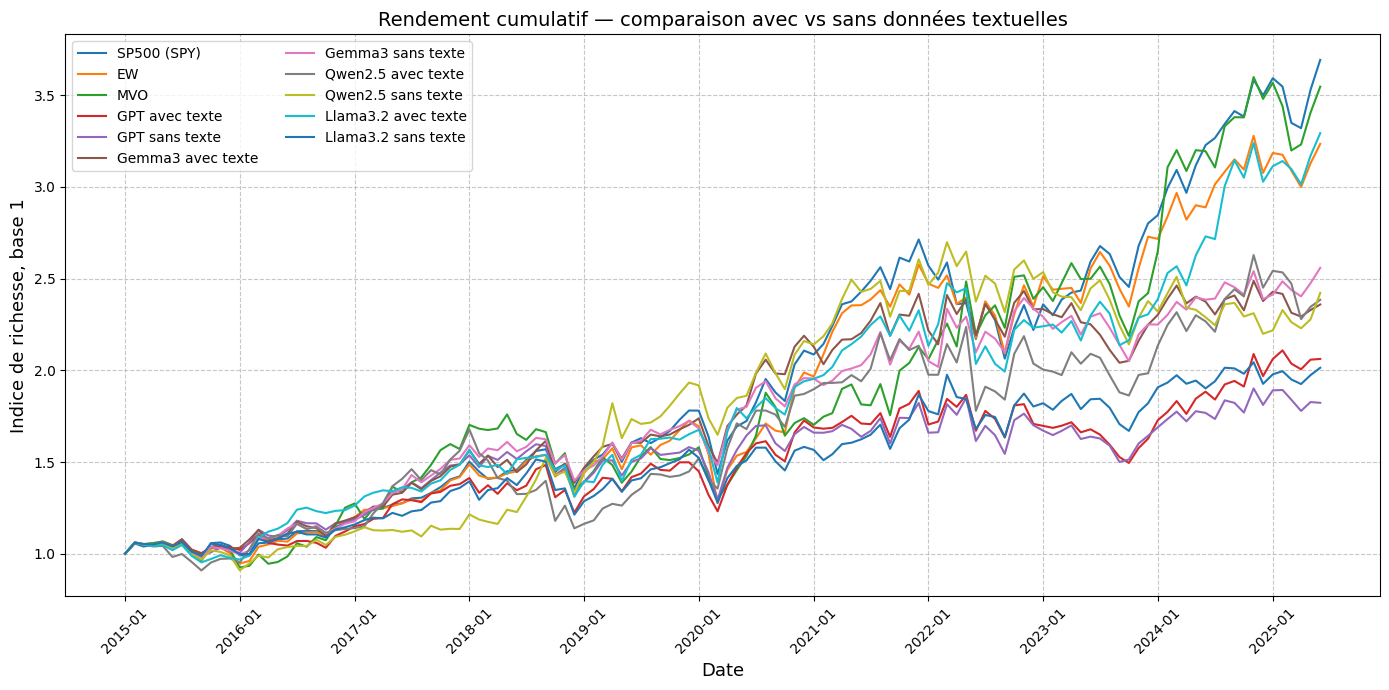

In [26]:
plt.figure(figsize=(14, 7))

for name, returns in series.items():
    wealth = make_wealth(returns, common_idx)
    plt.plot(wealth.index, wealth.values, label=name)

plt.grid(True, linestyle="--", alpha=0.7)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Indice de richesse, base 1", fontsize=13)
plt.title("Rendement cumulatif — comparaison avec vs sans données textuelles", fontsize=14)
plt.legend(loc="upper left", fontsize=10, ncol=2)

plt.gca().xaxis.set_major_locator(matplotlib.dates.YearLocator())
plt.gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


## 8. Graphiques par modèle — avec texte vs sans texte

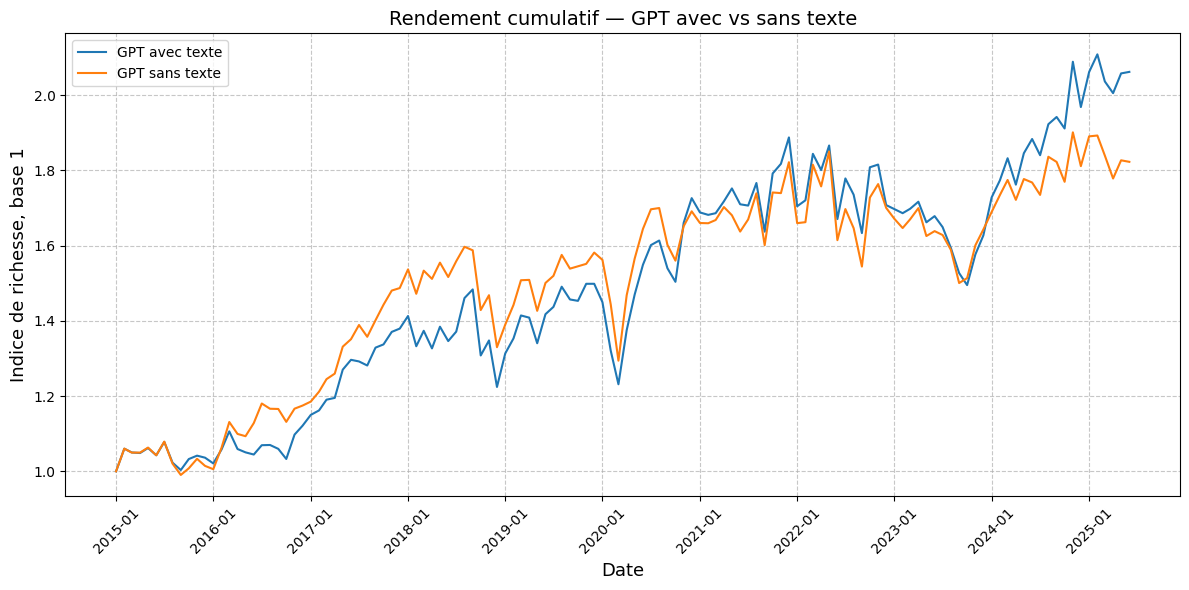

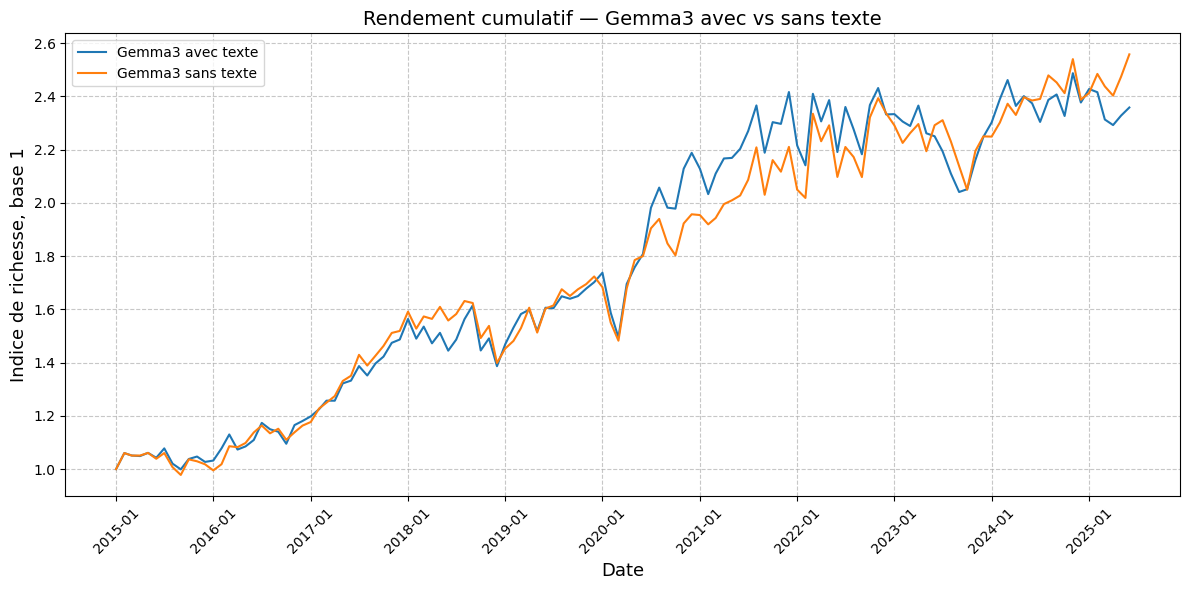

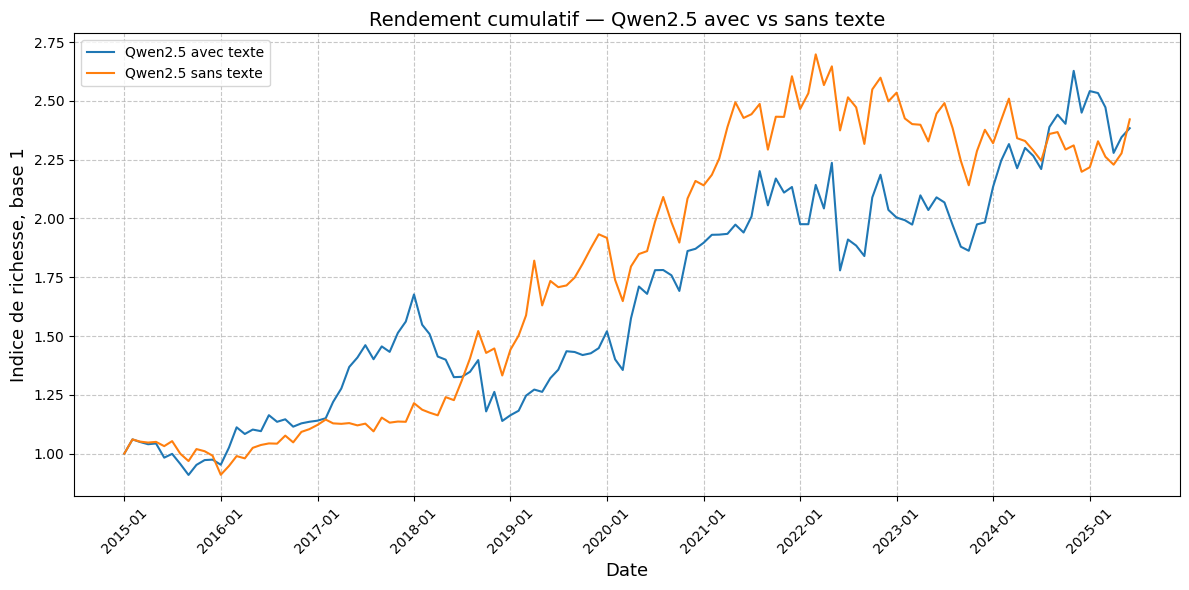

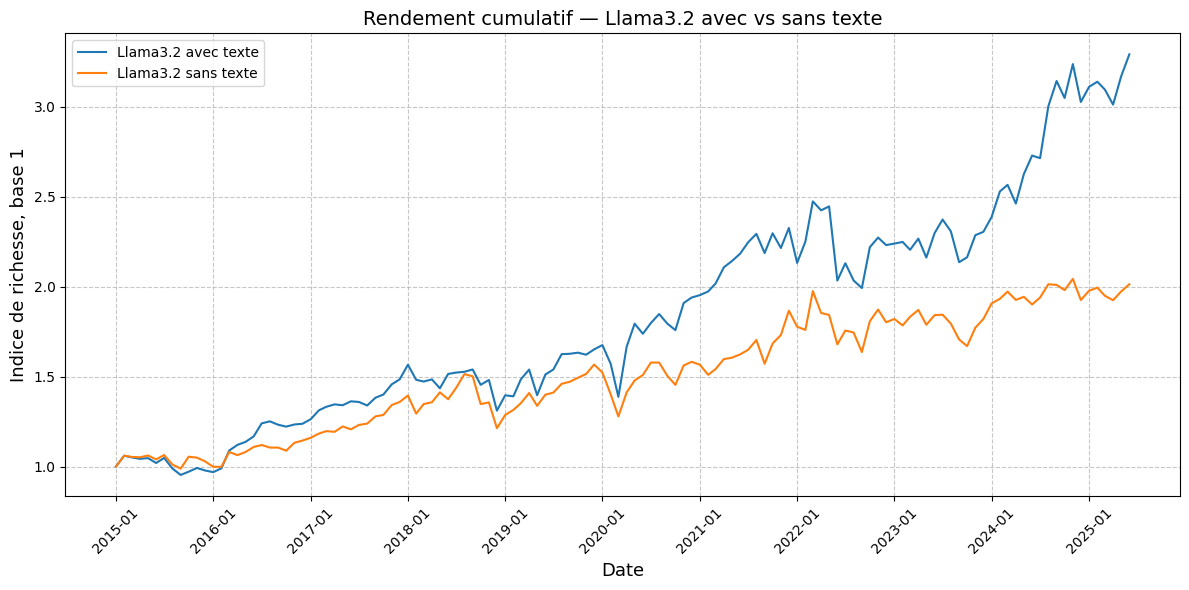

In [27]:
for model in MODELS:
    label = MODEL_LABELS.get(model, model)
    text_name = f"{label} avec texte"
    no_text_name = f"{label} sans texte"

    if text_name not in series or no_text_name not in series:
        print(f"[{label}] Série manquante, graphique ignoré.")
        continue

    plt.figure(figsize=(12, 6))

    for name in [text_name, no_text_name]:
        if name in series:
            wealth = make_wealth(series[name], common_idx)
            plt.plot(wealth.index, wealth.values, label=name)

    plt.grid(True, linestyle="--", alpha=0.7)
    plt.xlabel("Date", fontsize=13)
    plt.ylabel("Indice de richesse, base 1", fontsize=13)
    plt.title(f"Rendement cumulatif — {label} avec vs sans texte", fontsize=14)
    plt.legend(loc="upper left", fontsize=10)

    plt.gca().xaxis.set_major_locator(matplotlib.dates.YearLocator())
    plt.gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y-%m"))
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


## 9. Écart cumulatif par modèle

On trace ici la différence entre l’indice de richesse du portefeuille sans texte et celui avec texte.  
Une valeur positive indique que la version sans texte a accumulé plus de richesse que la version avec texte.

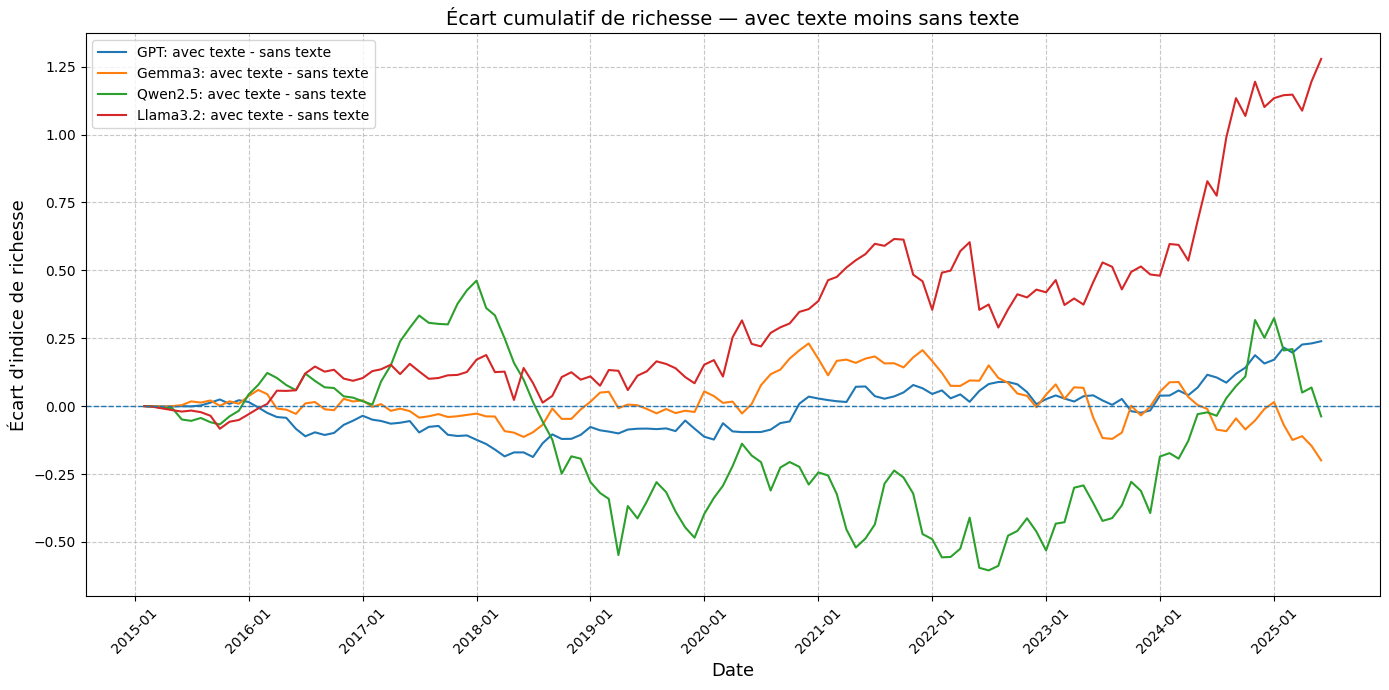

In [28]:
plt.figure(figsize=(14, 7))

for model in MODELS:
    label = MODEL_LABELS.get(model, model)
    text_name = f"{label} avec texte"
    no_text_name = f"{label} sans texte"

    if text_name not in series or no_text_name not in series:
        continue

    w_text = (1 + series[text_name].reindex(common_idx).astype(float)).cumprod()
    w_no_text = (1 + series[no_text_name].reindex(common_idx).astype(float)).cumprod()

    diff = w_text - w_no_text
    plt.plot(diff.index, diff.values, label=f"{label}: avec texte - sans texte")

plt.axhline(0, linestyle="--", linewidth=1)
plt.grid(True, linestyle="--", alpha=0.7)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Écart d'indice de richesse", fontsize=13)
plt.title("Écart cumulatif de richesse — avec texte moins sans texte", fontsize=14)
plt.legend(loc="best", fontsize=10)

plt.gca().xaxis.set_major_locator(matplotlib.dates.YearLocator())
plt.gca().xaxis.set_major_formatter(matplotlib.dates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
